MeanShift 추적 실습

- 색상기반 객체 추적
- 비슷한 색상 가진 영역 자동으로 따라가기
- 색상분포(히스토그램)를 기반 객체 추적
- 확률이 높은 방향으로 윈도우 이동 >> 최적 위치(x,y) 찾기
- 실시간 추적에 적합(아주 빠름)

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


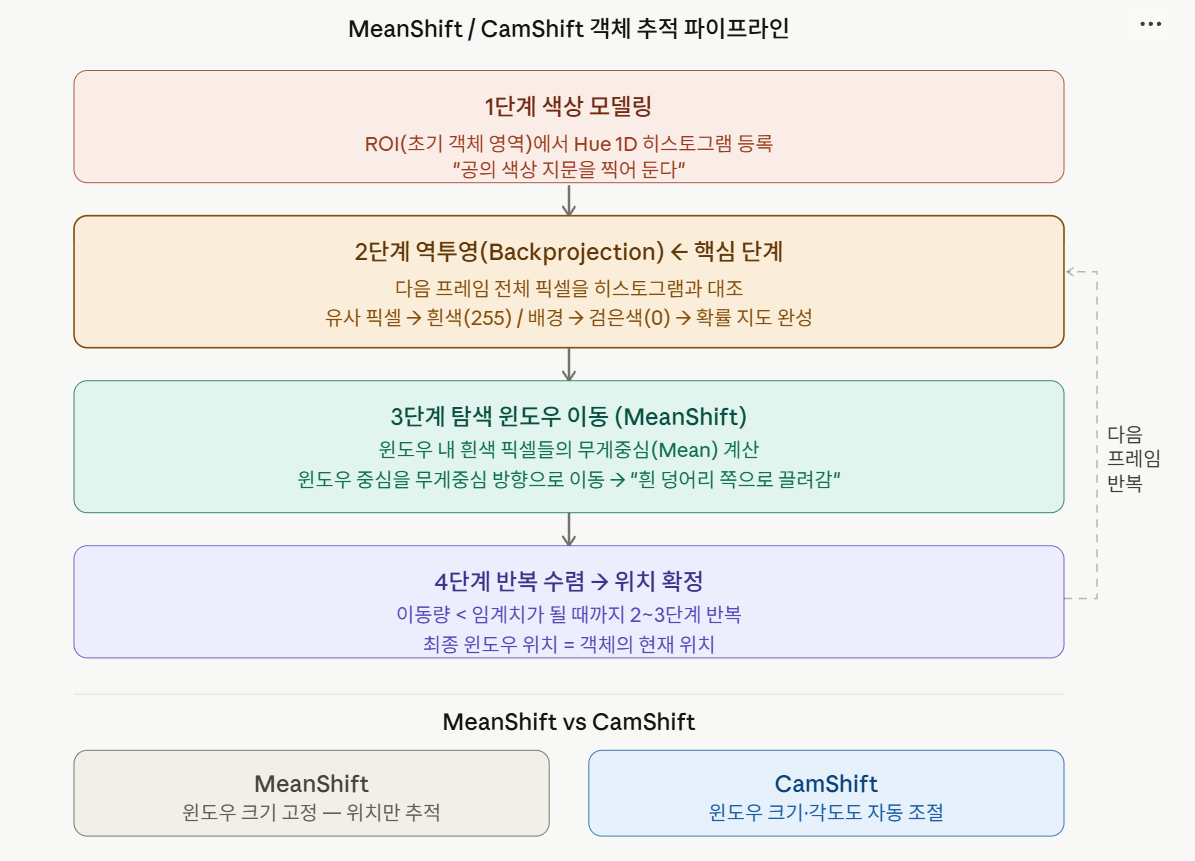

In [3]:
import numpy as np
import cv2
from google.colab.patches import cv2_imshow
import time

# 변수 초기 설정
roi_hist = None
# 추적 대상 객체의 정규화된 히스토그램 저장 변수 초기값 : None
# roi : region of interest : 관심영역 히스토그램 : 0~255의 색상분포를 막대그래프로? 0인 픽셀 몇개 이런느낌

win_name = 'MeanShift Tracking'

# MeanShift와 CamShift는 오차(EPS)또는 반복횟수(COUNT)중 하나라도 충족되면 중지됨
termination = (cv2.TERM_CRITERIA_EPS | cv2.TERM_CRITERIA_COUNT, 10, 1.0 )
# 이건 10번 반복 혹은 이동거리 1pixel미만이면 종료.

# 추적 대상 영역 : 바운딩 박스 -> 좌표를 저장할 전역 변수
# 원래는 cv2.selectROI로 하는데 코랩에서 못씀
# 그래서 초기값 하드코딩.
# (x,y) = 시작 좌표, (w,h) = 너비, 높이

x,y,w,h = 1150,400,100,100


In [4]:
video_path = '/content/drive/MyDrive/CV_work/AI_응용_강의자료/data/newyork.mp4'

In [12]:
cap = cv2.VideoCapture(video_path)
delay = int(1000/24)

if not cap.isOpened():
    print('오류 발생 : 비디오 파일을 열 수 없습니다. 파일을 업로드 했는지 확인해 주세요')
    exit()


frame_count = 0
MAX_FRAME_TO_PROCESS= 150 # 최대 150 프레임 -> 이미지 150장 까지 처리
DISPLAY_EVERY_N_FRAMES = 20 # 20 프레임 마다 결과 출력


print(f'MeanShift 추적 시작(최대 {MAX_FRAME_TO_PROCESS} 프레임, {DISPLAY_EVERY_M_FRAMES} 프레임 마다 출력 )')


MeanShift 추적 시작(최대 150 프레임, 20 프레임 마다 출력 )


In [6]:
# 첫 프레임에서 ROI 히스토그램 등록


ret, frame = cap.read()

if not ret:
    print('오류 발생')
    exit()


# 초기 추적 대상 영역(ROI) 추출

roi = frame[y:y+h, x:x+w] # frame 은 이미지가 나오고, 거기서 슬라이싱 한거임.

# ROI를 HSV 컬러로 변경
roi_hsv = cv2.cvtColor(roi, cv2.COLOR_BGR2HSV)

# ROI의 H채널에 대한 히스토그램 계산
roi_hist = cv2.calcHist([roi_hsv],[0],None,[180],[0,180]) # Hue의 범위가 opencv에서는 0~180이다.
# cv2.calcHist(img, 0번채널이 H채널, 마스크 여부, x갯수, y범위)

# 히스토그램 정규화 (0~255)
# 역투영 하려고(back projection) >> grayscale 이미지 표현
cv2.normalize(roi_hist, roi_hist,0,255, cv2.NORM_MINMAX)
# cv2.normalize(입력 데이터 : 색상 히스토그램, 출력될 데이터 지금은 덮어씌운거임.)
# 이래서 roi_hist가 두개인거지.

print(f'초기 추적 대상 영역 설정 완료 : (x = {x}, y= {y}, w = {w}, h = {h})')



초기 추적 대상 영역 설정 완료 : (x = 1150, y= 400, w = 100, h = 100)


역투영 (BACK-PROJECTION)(***)
-  이 픽셀이 가진 색상이 내가 찾는 색상일 확률은?

- 그럼 어떻게 하나?
  - 현재 픽셀의 h(hue) 값 확인 (예: 30도)
  - ROI(관심영역) 히스토그램에서 30도가 얼마나 나오는지(빈도) 확인
  - 그 빈도를 픽셀값으로 설정
  - 그 결과, 밝을 수록 유사한 색상이다라고 간주

In [13]:
# 비디오 처리 루프

while cap.isOpened() and frame_count < MAX_FRAME_TO_PROCESS:
    ret, frame = cap.read()
    if not ret:
        break


    img_draw = frame.copy()
    #  원본 이미지 위에 추적한 결과 그리기

    # 전체 영상이 BRG이라서 HSV로 바꿔주기
    hsv = cv2.cvtColor(frame,cv2.COLOR_BGR2HSV)

    # 전체 영상에 대해 ROI 히스토그램 역투영 (매우 중요)
    dst = cv2.calcBackProject([hsv],[0],roi_hist,[0,180],1) # 역추적한 결과는 흑백으로 나옴.

    # 각 픽셀이 ROI색상과 얼마나 유사한지 나타내는 확률맵 0~255
    # [hsv] : 대상 이미지
    # [0] : 대상 채널
    # [0,180] : H채널 범위
    # 1 : 결과물 크기 조절 비율(scale)

    # 역투영 결과(dst)와 이전 추적 위치로 평균 이동 추적 실행

    ret, (x,y,w,h) = cv2.meanShift(dst,(x,y,w,h),termination)

    # 새로운 위치에 초록색 사각형 표시
    cv2.rectangle(img_draw,(x,y),(x+w,y+h),(0,255,0),2)

    # 컬러 영상(추적 결과)와 역투영 영상(dst)를 좌우로 통합하여 출력
    result = np.hstack((img_draw,cv2.cvtColor(dst,cv2.COLOR_GRAY2BGR) ))

    # 특정 간격의 프레임만 표시
    if frame_count % DISPLAY_EVERY_N_FRAMES ==0:
        print(f'Frame {frame_count} MeanShift 추적 결과')
        cv2_imshow(result)
        time.sleep(1)

    frame_count+=1


cap.release()
# cv2.destroyAllWindows() #코랩에선 필요없는데 vscode같은 곳에선 팝업창 닫기.


Output hidden; open in https://colab.research.google.com to view.